In [1]:
import numpy as np 
import pandas  as pd

**Dataset Loading**

In [2]:
final_df = pd.read_csv('final_df.csv')


In [3]:
final_df.head(4)

,match_id,ball,city,batting_team,toss_decision,target,bowling_team,current_score,runs_left,balls_left,wickets_left,crr,rrr,result
0,153,1,Port Elizabeth,Royal Challengers Bangalore,bat,157,Mumbai Indians,44,114,77,7,6.139535,8.883117,0
1,139,3,Durban,Kings XI Punjab,bat,145,Royal Challengers Bangalore,97,49,27,7,6.258065,10.888889,0
2,7944,7,Bengaluru,Sunrisers Hyderabad,field,222,Royal Challengers Bangalore,187,36,11,8,10.293578,19.636364,0
3,7937,6,Indore,Kings XI Punjab,field,250,Kolkata Knight Riders,129,122,42,5,9.923077,17.428571,0


In [4]:
final_df.columns

Index(['match_id', 'ball', 'city', 'batting_team', 'toss_decision', 'target',
       'bowling_team', 'current_score', 'runs_left', 'balls_left',
       'wickets_left', 'crr', 'rrr', 'result'],
      dtype='object')

## Model 

In [5]:
final_df = final_df[['match_id', 'ball', 'city', 'batting_team', 'target', 'bowling_team','current_score', 'runs_left', 'balls_left', 'wickets_left', 'crr', 'rrr', 'result']]
final_df.columns

Index(['match_id', 'ball', 'city', 'batting_team', 'target', 'bowling_team',
       'current_score', 'runs_left', 'balls_left', 'wickets_left', 'crr',
       'rrr', 'result'],
      dtype='object')

**train-test-spliting**

In [6]:
X=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
y_train.head(4)

19174    1
24889    0
43328    0
48198    0
Name: result, dtype: int64

In [8]:
X_train.head(4)

,match_id,ball,city,batting_team,target,bowling_team,current_score,runs_left,balls_left,wickets_left,crr,rrr
19174,407,3,Bangalore,Royal Challengers Bangalore,117,Rajasthan Royals,5,113,111,10,3.333333,6.108108
24889,106,1,Mumbai,Mumbai Indians,189,Kings XI Punjab,159,31,17,5,9.262136,10.941176
43328,11140,2,Jaipur,Rajasthan Royals,200,Kings XI Punjab,79,122,70,9,9.480000,10.457143
48198,7924,2,Bengaluru,Mumbai Indians,173,Royal Challengers Bangalore,92,82,58,6,8.903226,8.482759


**Categorical to Numerical Feature Transformation**

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

trf = ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False, drop='first'), ['batting_team', 'bowling_team', 'city'])
], remainder='passthrough')


**Model training**

In [10]:
from xgboost import XGBClassifier

In [11]:
from sklearn.pipeline import Pipeline

In [12]:
model = XGBClassifier()

In [13]:
pipe = Pipeline(steps=[
    ('step1', trf),
    ('step2', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])


In [14]:
pipe.fit(X_train,y_train)

c:\DEKSTOP\DataScience\IPL\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:50:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\DEKSTOP\DataScience\IPL\venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1624: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=Non...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [15]:
X_train.describe()

,match_id,ball,target,current_score,runs_left,balls_left,wickets_left,crr,rrr
count,39021.000000,39021.000000,39021.000000,39021.000000,39021.000000,39021.000000,39021.000000,39021.000000,39021.000000
mean,2716.873504,3.595090,167.509136,73.755721,94.753415,62.604495,7.571795,7.471225,10.807100
std,4200.437305,1.807556,29.562934,47.259470,50.546390,33.340381,2.127799,2.294291,15.416679
min,1.000000,1.000000,67.000000,0.000000,-15.000000,-2.000000,0.000000,0.000000,-516.000000
25%,231.000000,2.000000,148.000000,34.000000,55.000000,34.000000,6.000000,6.275862,7.333333
50%,458.000000,4.000000,167.000000,70.000000,94.000000,63.000000,8.000000,7.500000,9.100000
75%,7894.000000,5.000000,187.000000,109.000000,132.000000,91.000000,9.000000,8.750000,11.239437
max,11415.000000,9.000000,250.000000,222.000000,250.000000,119.000000,10.000000,36.000000,684.000000


In [16]:
y_pred=pipe.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4549
           1       0.98      1.00      0.99      5207

    accuracy                           0.99      9756
   macro avg       0.99      0.99      0.99      9756
weighted avg       0.99      0.99      0.99      9756



In [18]:
accuracy_score(y_test,y_pred)

0.9894423944239442

In [19]:
print(confusion_matrix(y_test,y_pred))

[[4458   91]
 [  12 5195]]


In [20]:
pipe.predict_proba(X_test)[1]

array([0.08434045, 0.91565955], dtype=float32)

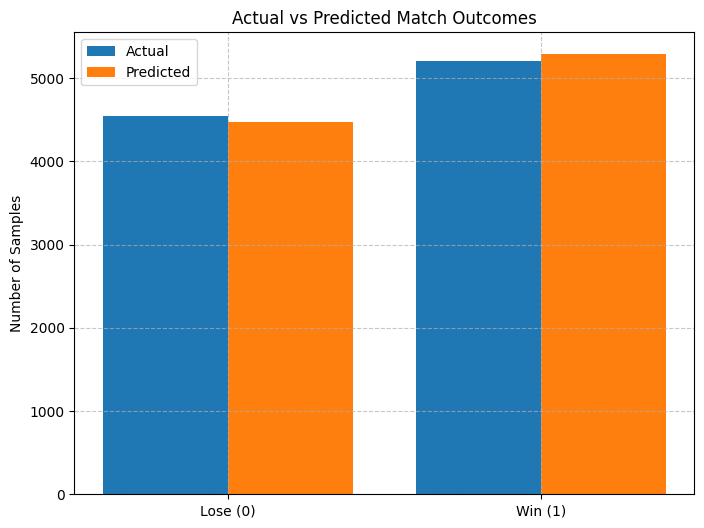

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count actual and predicted values
actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

# Plot side-by-side bar chart
labels = ['Lose (0)', 'Win (1)']
x = range(len(labels))   # x = [0, 1]   

plt.figure(figsize=(8, 6))
plt.bar(x, actual_counts, width=0.4, label='Actual', align='center')
plt.bar([i + 0.4 for i in x], predicted_counts, width=0.4, label='Predicted', align='center')
#Plots the predicted class distribution with a slight shift to the right (+0.4) so that they 
#appear side-by-side next to the actual bars.
plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel('Number of Samples')
plt.title('Actual vs Predicted Match Outcomes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)  #Adds a dashed grid to improve readability.
plt.show()

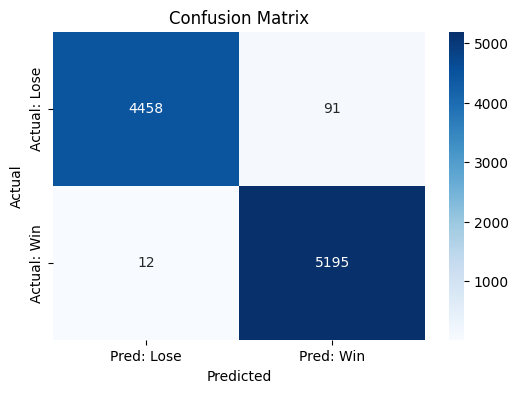

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Lose', 'Pred: Win'],
            yticklabels=['Actual: Lose', 'Actual: Win'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [23]:
import pickle


with open('model.pkl', 'wb') as file:
    pickle.dump(pipe, file)   